<a href="https://colab.research.google.com/github/TaisRol/AprendizajeAutomatico1/blob/main/ROLDAN_TP3_AA1_clasificaci%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP3 AA1 Clasificación

**Roldán Tais Maria Salome**

## Indicaciones básicas

0) Debe usar este notebook como template para su entrega. Haga una copia y comience a completar las consignas.

1) Cada uno debe completar las consignas indicadas en este notebook.

2)
3) No pueden repetir el mismo dataset que ya haya definido un compañero.

4) copias explícitas de secciones enteras del trabajo de otro será penalizado disminuyendo su puntuación.

5) No se olvide de añadir las fuentes de inspiración de su código (blogs, prompts de chatgpt o similar).

6) Además de todo el código que agregue, es importante que sepa interpretarlo. Agregue texto explicativo en cada sección. Esto le ayudará al momento del coloquio / parcial

7) Revise las fecha límite de entrega de este trabajo

# ENTREGA

**LEA LAS INDICACIONES DE ENTREGA EN EL FORO DE LA TAREA**

#**Tarea: Entrenamiento y evaluación de clasificadores**  

**Objetivo**: Aplicar un modelo de clasificación a un dataset de su elección, procesar dicho dataset para poder usarlo para entrenamiento, indicar y compartir todos los recursos utilizados, evaluar su rendimiento.

---

# **Instrucciones**:

#1. **Selección del Dataset**  
   - Elijan un dataset de UCI ML Repository del siguiente enlace: https://archive.ics.uci.edu/datasets?Task=Classification&skip=0&take=10&sort=desc&orderBy=Relevance&search=
   - Requisitos:  
     - Debe tener al menos 4 variables.
     - Revisar en el foro de la tarea que dicho dataset no haya sido ya elegido por otra persona.
     - Postee en el foro de la tarea el dataset que eligió. Continue al siguiente punto.  



## Resolución:

El dataset que voy a usar es Car valuation, cuyo objetivo va a ser evaluar la calidad de un auto, en "aceptable, no aceptable, bueno y muy bueno"

In [5]:
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data -O car.data


--2025-11-15 04:16:32--  https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘car.data’

car.data                [  <=>               ]  50.65K   148KB/s    in 0.3s    

2025-11-15 04:16:33 (148 KB/s) - ‘car.data’ saved [51867]




## 2. **Análisis exploratorio (previo al modelado)**  
   - Describan las variables (media, distribución, outliers).  
   - Visualizen:  
     - Histogramas o boxplots para ver distribuciones.  
     - Gráficos de dispersión (scatterplots) entre features y target.  
   - Describan si observan o no relaciones entre algunas variables.  


## Resolución:

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
columns = ["buying", "maint", "doors", "persons", "lug_boot", "safety", "class"]
df = pd.read_csv("car.data", names=columns)

Ahora voy a renombrar mis columnas y voy a traducir las categorias de "clase", el resto no cambio porque son más intuitivas

In [7]:
#Renombro las columnas
df = df.rename(columns={
    "buying": "compra",
    "maint": "mantenimiento",
    "doors": "puertas",
    "persons": "personas",
    "lug_boot": "baul",
    "safety": "seguridad",
    "class": "clase"
})

#Renombro las categorias de clase
df["clase"] = df["clase"].replace({
    "unacc": "noacep",
    "acc": "acep",
    "good": "bueno",
    "vgood": "muybueno"
})

In [8]:
print(df.head())
print(df.shape)

  compra mantenimiento puertas personas   baul seguridad   clase
0  vhigh         vhigh       2        2  small       low  noacep
1  vhigh         vhigh       2        2  small       med  noacep
2  vhigh         vhigh       2        2  small      high  noacep
3  vhigh         vhigh       2        2    med       low  noacep
4  vhigh         vhigh       2        2    med       med  noacep
(1728, 7)


###Distribución de variables
Mi dataset no tiene variables numericas asi que no usaré heatmaps

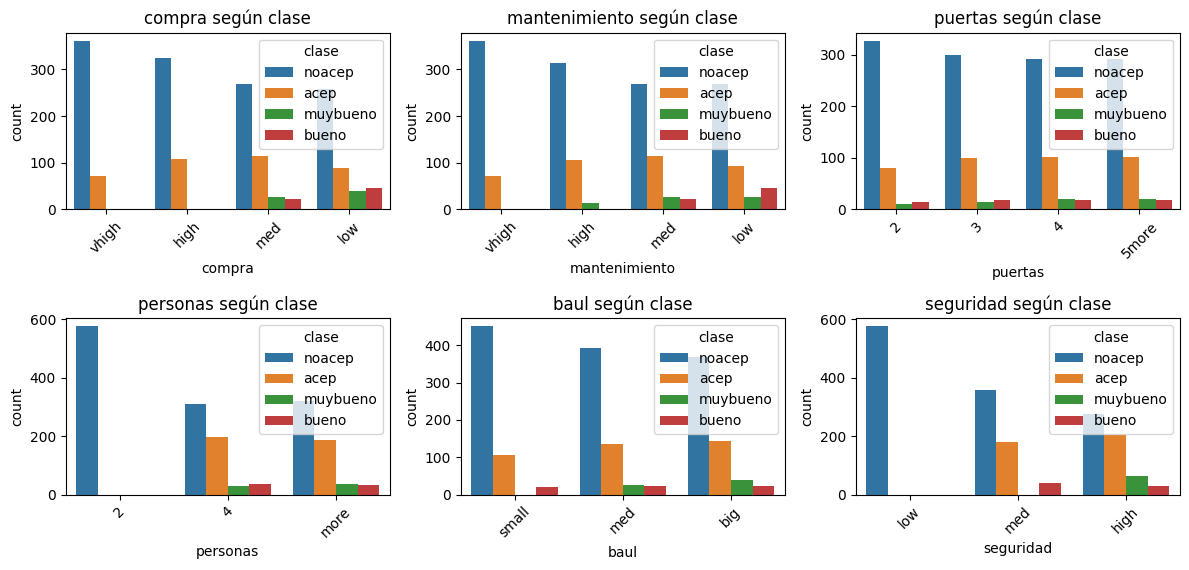

In [9]:
plt.figure(figsize=(12,8))
for i, col in enumerate(df.columns[:-1], 1):  # excluye target
    plt.subplot(3, 3, i)
    sns.countplot(data=df, x=col, hue="clase")
    plt.xticks(rotation=45)
    plt.title(f"{col} según clase")
plt.tight_layout()
plt.show()


Con estos graficos podemos determinar que "seguridad" y "personas" son los parametros más importantes, ya que tienen valores en los que son %100 no aceptables. En cambio la variable "puertas" es la menos importante ya que sin importar la cantidad de puertas que presente un auto, el nivel de aceptacion son muy similares, lo mismo pasa con el tamaño del baul.

## 3. **Preprocesamiento**  
   - Limpieza: Manejen missing values (eliminar, imputar) y outliers (si es necesario).  
   - Limpieza: indique cuáles features descarta. Justifique.
   - Indique si usará o no variables categóricas. Justifique. Realice su preprocesamiento adeucado.
   - Otros pasos que crea conveniente para pre-procesar el dataset (mencione y explique)

Detalla las caracteristicas del dataset como nro de variables, nro de filas o instancias, si el problema es clasificacion binaria o multiclase, y otras características que crea conveniente.

Realice la división de datos (entrenamiento / testeo / CV según corresponda)

## Resolución:

Mi dataset no tiene missing values y mucho menos outliers ya que todas mis variables son categoricas.

Voy a descartar el feature "puertas" ya que como vimos en los graficos, no importa la cantidad de puertas, su nivel de aceptacion es casi el mismo.

In [10]:
df = df.drop('puertas', axis=1)
print(df.columns)

Index(['compra', 'mantenimiento', 'personas', 'baul', 'seguridad', 'clase'], dtype='object')


También decidi agrupar las categorias dentro de clase:
en vez de ser 4, hice solamente 2, colocando "bueno" y "muy bueno" en aceptable.

In [11]:
# Cambiar clase: bueno y muybueno → acep
df_binario = df.copy()
df_binario['clase'] = df_binario['clase'].replace({
    'bueno': 'acep',
    'muybueno': 'acep'
})

# Verificar
print(df_binario['clase'].value_counts(normalize=True))

clase
noacep    0.700231
acep      0.299769
Name: proportion, dtype: float64


Como Logistic regression solo acepta variables numericas, voy a transformar mis variables con One-Hot Encoding



In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

X = df_binario.drop('clase', axis=1)
y = df_binario['clase']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

preprocessor = ColumnTransformer([
    ('onehot', OneHotEncoder(drop='first'), X.columns)
])

X_train_enc = preprocessor.fit_transform(X_train)
X_test_enc = preprocessor.transform(X_test)




## 4. **Clasificación con logistic regression**  
   

En este apartado entrenará un clasificador con la librería sklearn usando logistic regresion.

### 4.1 Entrenamiento y evaluación

In [15]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train_enc, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

### 4.2 Métricas de evaluación

Muestre el desempeño en el conjunto de datos de entrenamiento y testeo.
Mencione las métricas utilizadas. No se olvide de mostrar la matriz de confusión.
Explique los resultados obtenidos.

In [16]:
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Predicciones
y_train_pred = model.predict(X_train_enc)
y_test_pred = model.predict(X_test_enc)

# Accuracy
acc_train = accuracy_score(y_train, y_train_pred)
acc_test = accuracy_score(y_test, y_test_pred)

# Mostrar resultados
print("MÉTRICAS")
print("-" * 40)
print(f"Accuracy en entrenamiento : {acc_train:.4f}  ({acc_train*100:.1f}%)")
print(f"Accuracy en prueba        : {acc_test:.4f}  ({acc_test*100:.1f}%)")
print("-" * 40)

MÉTRICAS
----------------------------------------
Accuracy en entrenamiento : 0.9407  (94.1%)
Accuracy en prueba        : 0.9538  (95.4%)
----------------------------------------


El hecho de que el rendimiento en prueba haya sido ligeramente mejor que en el de entrenamiento indica que el modelo generaliza bien y no presenta un sobreajuste.

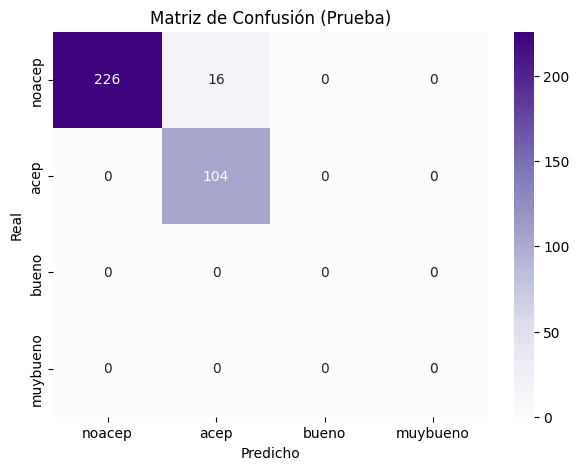

In [17]:
#Matriz de confusión
cm = confusion_matrix(y_test, y_test_pred, labels=['noacep', 'acep', 'bueno', 'muybueno'])

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['noacep', 'acep', 'bueno', 'muybueno'],
            yticklabels=['noacep', 'acep', 'bueno', 'muybueno'])
plt.title('Matriz de Confusión (Prueba)')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()

La matriz de confusión muestra que el modelo clasifica correctamente la mayoría de los casos “noacep” y coreectamente el total de “acep”, pero no logra identificar las clases “bueno” y “muybueno”

## 5- **Otro clasificador**

### 5.1 Elija otro modelo para entrenar un clasificador

Elija alguno de los modelos vistos: kNN, SVM o MLP para entrenar un clasificador usando los parámetros por defecto de sklearn.

Justifique su elección.

### 5.2 Entrenamiento del modelo.

Voy a usar el modelo de MLP por que tiene una buena capacidadd para modelar relaciones no lineales complejas, como las que se encuentran entre las variables de este dataset.

In [18]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# --- MLP con parámetros por defecto ---
mlp = MLPClassifier(random_state=42)

# Entrenamiento
mlp.fit(X_train_enc, y_train)

# Predicciones
y_train_pred = mlp.predict(X_train_enc)
y_test_pred = mlp.predict(X_test_enc)

# --- MÉTRICAS
print("MLP")
print("-" * 50)
print(f"Accuracy (train): {accuracy_score(y_train, y_train_pred):.4f}  →  {accuracy_score(y_train, y_train_pred)*100:.1f}%")
print(f"Accuracy (test) : {accuracy_score(y_test, y_test_pred):.4f}  →  {accuracy_score(y_test, y_test_pred)*100:.1f}%")
print("-" * 50)

MLP
--------------------------------------------------
Accuracy (train): 0.9740  →  97.4%
Accuracy (test) : 0.9769  →  97.7%
--------------------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Con un 97% de accuracy se puede decir que el modelo de MLP predice bien, y esta funcionando correctamente.

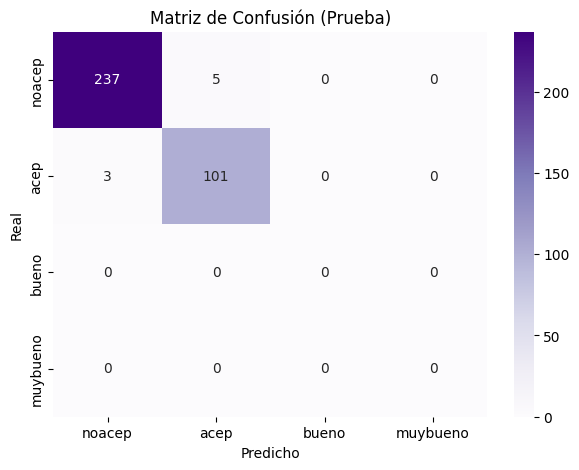

In [19]:
# --- Predicción del modelo MLP ---
y_test_pred = mlp.predict(X_test_enc)

# --- Matriz de confusión ---
cm = confusion_matrix(y_test, y_test_pred, labels=['noacep', 'acep', 'bueno', 'muybueno'])

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['noacep', 'acep', 'bueno', 'muybueno'],
            yticklabels=['noacep', 'acep', 'bueno', 'muybueno'])
plt.title('Matriz de Confusión (Prueba)')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()

Esta matriz de confunción podemos compararla con la que hicimos anteriormente y podemos decir que si bien no tuvo la misma cantidad de errores que la otra (esta tuvo menos), si clasifico mal tambien autos que tendrian que ir en acep, cosa que con el anterior modelo no ocurria, pero el error es tan pequeño que carece de importancia.

### 5.3 Evaluación del desempeño

In [21]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

        acep       0.95      0.97      0.96       104
      noacep       0.99      0.98      0.98       242

    accuracy                           0.98       346
   macro avg       0.97      0.98      0.97       346
weighted avg       0.98      0.98      0.98       346



## 6  Tuneo de hiperparámetros

En esta sección debe modificar probar cómo la modificación de un hiperparámetro del modelo elegido en punto 5) afecta en los resultados.

Justifique y realice el experimento en esta sección.



*   Aca simplemente lo que hice fue cambiar la configuracion por defecto a uno con mas cantidad, en vez de una capa oculta solo agregue una mas (en total 2 capas ocultas) una de 100 y otra de 50, este modelo mas complejo logro un accuracy de 0.93 en prueba, superando al anterior modelo.
En conclusión, al aumentar la ocmplejidad del MLP se mejoró el desempeño sin sobreajuste significativo.



In [22]:
mlp_complex = MLPClassifier(hidden_layer_sizes=(100, 50), random_state=42, max_iter=500)
mlp_complex.fit(X_train_enc, y_train)
acc_complex = accuracy_score(y_test, mlp_complex.predict(X_test_enc))

print(f"MLP complejo: {acc_complex:.4f}")

MLP complejo: 0.9740


## 6- Conclusiones

Fundamente, justifique con sus palabras.



*   En este trabajo clasifiqué la calidad de autos utilizando el dataset de Car Evaluation, clasificandolos en "aceptable y no aceptable", luego de eliminar la variable "puertas" por su baja relevancia y aplicando One Hot encoding a mis variables categoricas pude entrenar 2 modelos que dieron ambos resultados muy buenos, el primero de Regresion logistica que tuvo muy buenos porcentajes al tener un 95.4% en prueba y luego el de MLP que logro un accuracy del 97.7%.

El MLP superó las metricas de la regresión logística aunque solo por un 3% se consolidó como un mejor modelo para este problema.


# Referencias

Mencione los recursos utilizados

# BONUS 1

Si su dataset estaba relativamente balanceado, como bonus pruebe entrenar otro modelo clasificador diferente y comparar resultados con su clasificador elegido en 5) y el modelo elegido 6) luego del tuneo de hiperparámetros.



# BONUS 2

Si su dataset estaba desbalanceado, puebe utilizar alguna técnica para lidiar con el desbalance de clases durante el entrenamiento.

1) Ofrezca una comparativa de entrenar y evaluar modelos de Logistic regression con y sin class_weight='balanced' o el modelo SVC con y sin class_weight='balanced'

2) Pruebe entrenar KNN con y sin uso de SMOTE

( Ver apunte sobre Desbalance de clases de la cátedra )

